# RQ2: Fusion Gains and Heterogeneity

## Research Question
Does broader multi-view graph fusion improve station-level forecasting relative to best two-view fusion?

## Hypothesis
H2: The all-view configuration (SD+DE+DC+ATD) outperforms the best two-view fusion in test WMAPE.

In [1]:
from pathlib import Path
import json
import sys
import numpy as np
import pandas as pd
import polars as pl
import seaborn as sns
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == 'notebooks' else Path.cwd().resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from scripts.notebook_reporting import canon_graph_set, optional_csv, parse_fusion_weights, relative_change, require_csv

ARTIFACT_ROOT = PROJECT_ROOT / 'data' / 'artifacts' / 'experiments'
sns.set_theme(style='whitegrid', context='talk')

c:\Users\stefa\OneDrive\Documents\uni\master's\EIT\Aalto\multidisciplinary_research\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
rq_results = require_csv('rq_runner/results.csv', required_columns=('rq', 'aggregation', 'graph_set', 'model', 'test_wmape'))
rq2_rows = rq_results.filter((pl.col('rq') == 'RQ2') & (pl.col('aggregation') == 'station') & (pl.col('model') == 'graph_propagation')).to_pandas()
rq2_rows['graph_set'] = rq2_rows['graph_set'].apply(canon_graph_set)
rq2_rows = rq2_rows.sort_values('test_wmape').reset_index(drop=True)

milestones = optional_csv('stgnn_milestones/milestone_results.csv', required_columns=('milestone', 'aggregation', 'fusion_mode', 'graph_set', 'test_wmape', 'fusion_weights'))

provenance = pd.DataFrame([
    {'artifact': 'rq_runner/results.csv', 'exists': (ARTIFACT_ROOT / 'rq_runner' / 'results.csv').exists()},
    {'artifact': 'stgnn_milestones/milestone_results.csv', 'exists': (ARTIFACT_ROOT / 'stgnn_milestones' / 'milestone_results.csv').exists()},
    {'artifact': 'stgnn_milestones/metadata.json', 'exists': (ARTIFACT_ROOT / 'stgnn_milestones' / 'metadata.json').exists()},
])

inclusion = pd.DataFrame([
    {'criterion': 'RQ2 graph_propagation rows', 'value': int(len(rq2_rows))},
    {'criterion': 'Any all-view row', 'value': bool((rq2_rows['graph_set'] == 'SD+DE+DC+ATD').any())},
    {'criterion': 'Any two-view row', 'value': bool((rq2_rows['graph_set'].str.count(r'\+') == 1).any())},
])

provenance, inclusion

(                                 artifact  exists
 0                   rq_runner/results.csv    True
 1  stgnn_milestones/milestone_results.csv    True
 2          stgnn_milestones/metadata.json    True,
                     criterion value
 0  RQ2 graph_propagation rows     4
 1            Any all-view row  True
 2            Any two-view row  True)

In [3]:
best_all_view = rq2_rows.loc[rq2_rows['graph_set'] == 'SD+DE+DC+ATD', 'test_wmape']
best_two_view = rq2_rows.loc[rq2_rows['graph_set'].str.count(r'\+') == 1, 'test_wmape']

rq2_effect = pd.DataFrame()
if len(best_all_view) > 0 and len(best_two_view) > 0:
    all_view = float(best_all_view.min())
    two_view = float(best_two_view.min())
    rq2_effect = pd.DataFrame([
        {
            'comparison': 'All-view vs best two-view',
            'all_view_test_wmape': all_view,
            'best_two_view_test_wmape': two_view,
            'absolute_delta': all_view - two_view,
            'relative_delta': relative_change(all_view, two_view),
        }
    ])

rq2_rows, rq2_effect

(       experiment_id   rq aggregation     graph_set  \
 0  RQ2_SD_DE_STATION  RQ2     station         SD+DE   
 1  RQ2_DE_DC_STATION  RQ2     station         DE+DC   
 2    RQ2_ALL_STATION  RQ2     station  SD+DE+DC+ATD   
 3  RQ2_SD_DC_STATION  RQ2     station         SD+DC   
 
                            description              model          config  \
 0             Two-view fusion: SD + DE  graph_propagation  {"alpha": 0.5}   
 1             Two-view fusion: DE + DC  graph_propagation  {"alpha": 0.5}   
 2  All-view fusion: SD + DE + DC + ATD  graph_propagation  {"alpha": 0.5}   
 3             Two-view fusion: SD + DC  graph_propagation  {"alpha": 0.5}   
 
    n_nodes  n_train_steps  n_validation_steps  n_test_steps  validation_wmape  \
 0      449          47463                5136         13915          0.795532   
 1      449          47463                5136         13915          0.805137   
 2      449          47463                5136         13915          0.808920  

In [4]:
fusion_weight_rows = []

if milestones is not None:
    learned = milestones.filter((pl.col('fusion_mode') == 'learned') & (pl.col('aggregation') == 'station')).to_pandas()
    for _, row in tqdm(learned.iterrows(), total=len(learned), desc='Parsing learned fusion weights', unit='run'):
        weights = parse_fusion_weights(row.get('fusion_weights'))
        for idx, value in enumerate(weights):
            fusion_weight_rows.append({
                'graph_set': row.get('graph_set'),
                'weight_index': idx,
                'weight': float(value),
            })

fusion_weights_df = pd.DataFrame(fusion_weight_rows)
if not fusion_weights_df.empty:
    fusion_weights_df.groupby('weight_index', as_index=False)['weight'].mean().sort_values('weight_index')
else:
    print('No learned fusion weights available for interpretation.')

Parsing learned fusion weights: 100%|██████████| 1/1 [00:00<00:00, 918.19run/s]

No learned fusion weights available for interpretation.


C:\Users\stefa\AppData\Local\Temp\ipykernel_13528\2021766921.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=rq2_rows, x='graph_set', y='test_wmape', palette='mako')


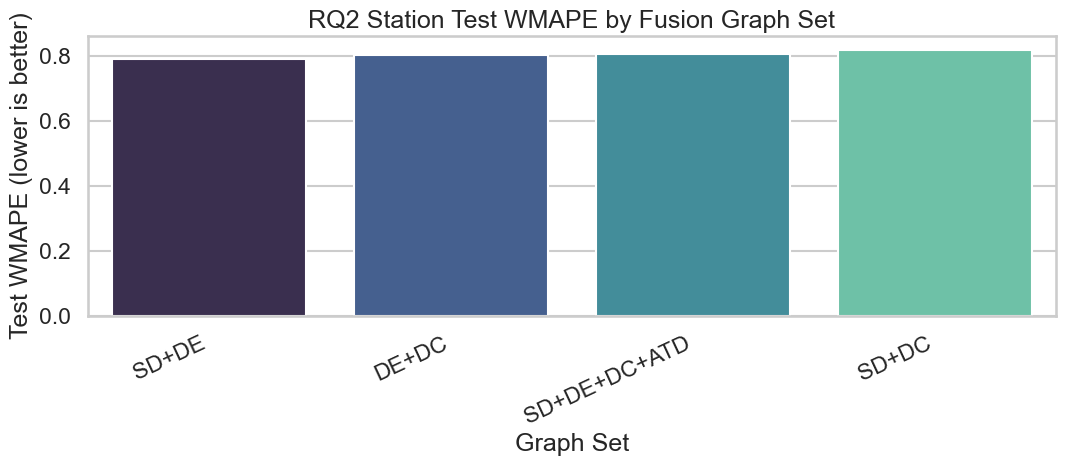

In [5]:
plt.figure(figsize=(11, 5))
ax = sns.barplot(data=rq2_rows, x='graph_set', y='test_wmape', palette='mako')
ax.set_title('RQ2 Station Test WMAPE by Fusion Graph Set')
ax.set_xlabel('Graph Set')
ax.set_ylabel('Test WMAPE (lower is better)')
for label in ax.get_xticklabels():
    label.set_rotation(25)
    label.set_horizontalalignment('right')
plt.tight_layout()
plt.show()

In [6]:
if milestones is None:
    print('Milestone artifact unavailable for fusion-mode sensitivity block.')
    fusion_mode_summary = pd.DataFrame()
else:
    fusion_mode_summary = milestones.filter((pl.col('milestone') == 'M3.2_multi_graph_fusion') & (pl.col('aggregation') == 'station')).select(['fusion_mode', 'graph_set', 'validation_wmape', 'test_wmape']).sort('test_wmape').to_pandas()

fusion_mode_summary

,fusion_mode,graph_set,validation_wmape,test_wmape
0,learned,DE+DC,0.885381,0.880258
1,equal,DE+DC,0.885388,0.880265


## Threats To Validity (RQ2)

- RQ2 all-view conclusions depend on the predefined fusion graph inventory (SD/DE/DC/ATD).
- Learned fusion weight interpretation is descriptive unless repeated across multiple seeds and folds.
- Any missing milestone rows reduce interpretability of heterogeneity evidence.

In [7]:
if rq2_effect.empty:
    status = 'insufficient_data'
    rationale = 'Cannot compare all-view to best two-view due to missing rows.'
else:
    delta = float(rq2_effect['absolute_delta'].iloc[0])
    status = 'supported' if delta < 0 else 'mixed_or_not_supported'
    rationale = f'All-view minus best-two-view test_wmape = {delta:.6f}'

pd.DataFrame([{'rq': 'RQ2', 'claim_status': status, 'rationale': rationale}])

,rq,claim_status,rationale
0,RQ2,mixed_or_not_supported,All-view minus best-two-view test_wmape = 0.01...
